# Playground to manually test a few architectures/hyperparameters
## Train LSTM pipeline and plot rolling forecasts for test profiles

In [1]:
from pathlib import Path

from rabl.machine_learning.lstm_pipeline import (
    LSTMPipeline,
    LSTMPipelineConfig,
    test_and_save_forecasts,
    clear_cuda_cache,
)

In [2]:
batch_size = 256
epochs = 25
seed = 123
max_plots = 5

n_lstm = 2
lstm_hidden = 128              # shared across stacked layers
lstm_dropout = 0.3            # ignored if n_lstm == 1 in nn.LSTM

n_fc = 1
fc_hidden = (64,)

learning_rate = 1e-3


h5_path = Path("../outputs/datasets/lstm_merged_batches_0001-0002_k4_standard_train0.70_val0.15_test0.15.h5")
out_dir = Path("../outputs/ml_results/training_playground/")
out_dir.mkdir(parents=True, exist_ok=True)

print("h5_path exists:", h5_path.exists())
print("out_dir:", out_dir)

h5_path exists: True
out_dir: ..\outputs\ml_results\training_playground


In [3]:
config = LSTMPipelineConfig(
    h5_path=h5_path,
    batch_size=batch_size,
    seed=seed,
    n_lstm=n_lstm,
    lstm_hidden=lstm_hidden,
    lstm_dropout=lstm_dropout,
    n_fc=n_fc,
    fc_hidden=tuple(fc_hidden),
    learning_rate=learning_rate,
)

pipeline = LSTMPipeline(config)

datasets = pipeline.build()
pipeline.inspect()

Dataset summary:
  H5 path:         ..\outputs\datasets\lstm_merged_batches_0001-0002_k4_standard_train0.70_val0.15_test0.15.h5
  Batch size:      256
  Seed:            123

  Train profiles:  1400
  Val profiles:    300
  Test profiles:   300

  Sample X shape:  (2001, 5, 14)   (per-sample)
  Sample Y shape:  (2001, 13)   (per-sample)

  Train samples:   2,801,400  (~10,943 batches)
  Val samples:     600,300  (~2,345 batches)
  Test samples:    600,300  (profiles used for forecasting)

  loader cardinality (derived from precomputed counts):
    train:          10943
    val_samples:    2345
    val_profile_ds: 300
    test_profile_ds:300

Train batch X shape: torch.Size([256, 5, 14])
Train batch Y shape: torch.Size([256, 13])

Val profile: results_drum_profile_00006
  X profile shape: torch.Size([2001, 5, 14])
  Y profile shape: torch.Size([2001, 13])

Test profile: results_drum_profile_00004
  X profile shape: torch.Size([2001, 5, 14])
  Y profile shape: torch.Size([2001, 13])



Using GPU: NVIDIA GeForce RTX 4060 Ti

LSTMRegressor architecture:
  Input features: 14
  LSTM layers (2): hidden_size=128, dropout=0.3
  FC layers (1): [64]
  Output targets: 13



Train 1/25: 10943batch [00:51, 210.83batch/s, loss=0.004269]
Val 1/25: 2345batch [00:06, 345.16batch/s]


Epoch 1/25 - loss: 0.017168 - val_loss: 0.009924 - data_time: 0.00s - compute_time: 23.83s - val_time: 6.80s - max_cuda_mem: 45.52 MB


Train 2/25: 10943batch [00:49, 219.96batch/s, loss=0.003628]
Val 2/25: 2345batch [00:06, 361.11batch/s]


Epoch 2/25 - loss: 0.005798 - val_loss: 0.008288 - data_time: 0.00s - compute_time: 23.79s - val_time: 6.50s - max_cuda_mem: 45.52 MB


...

Epoch 23/25 - loss: 0.001002 - val_loss: 0.009779 - data_time: 0.00s - compute_time: 25.95s - val_time: 6.51s - max_cuda_mem: 45.52 MB


Train 24/25: 10943batch [00:49, 219.48batch/s, loss=0.000770]
Val 24/25: 2345batch [00:06, 362.00batch/s]


Epoch 24/25 - loss: 0.000971 - val_loss: 0.009966 - data_time: 0.00s - compute_time: 23.59s - val_time: 6.48s - max_cuda_mem: 45.52 MB


Train 25/25: 10943batch [00:49, 219.36batch/s, loss=0.000509]
Val 25/25: 2345batch [00:06, 362.61batch/s]


Epoch 25/25 - loss: 0.000932 - val_loss: 0.013739 - data_time: 0.00s - compute_time: 23.65s - val_time: 6.47s - max_cuda_mem: 45.52 MB
Saved training curves to ..\outputs\ml_results\training_playground\lstm_train_val_curve.png
Finished training using device: cuda:0


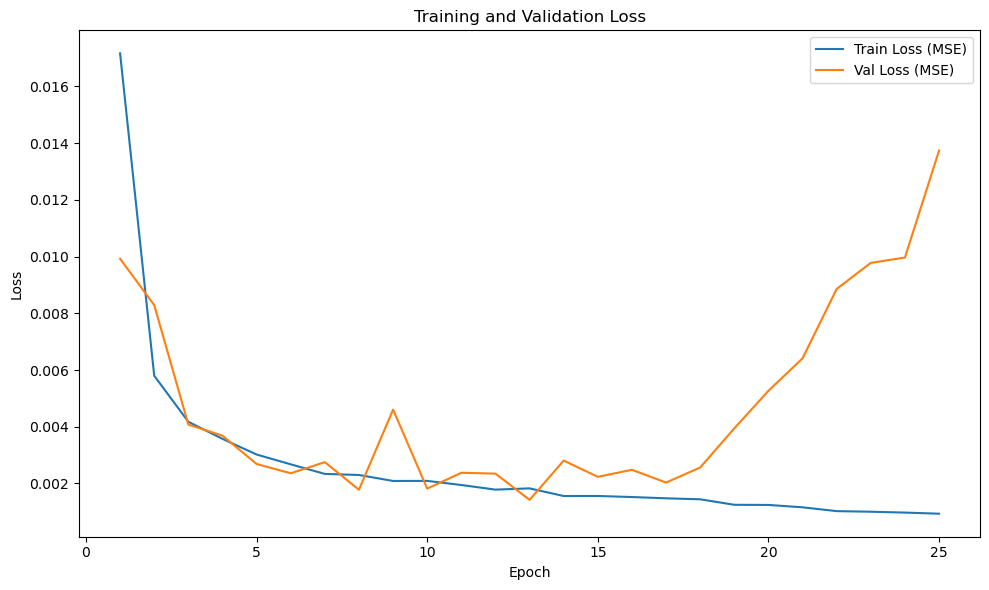

In [4]:
model, history, used_device = pipeline.train(epochs=epochs, out_dir=out_dir)
print(f"Finished training using device: {used_device}")

In [5]:
test_and_save_forecasts(
    model,
    datasets["test_profile_ds"],
    out_dir=out_dir,
    state_dim=pipeline.config.state_dim,
    control_channel=pipeline.config.control_channel,
    target_names=pipeline.config.target_names,
    max_plots=max_plots,
    plot_callback=pipeline.plot,
    h5_path=h5_path,
)

if "cuda" in str(used_device).lower():
    print(f"Clearing {used_device}...")
    del model
    clear_cuda_cache()

Forecast profiles: 1profile [00:02,  2.38s/profile, mse=8.705034e+08]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00004.png


Forecast profiles: 2profile [00:04,  2.38s/profile, mse=2.052291e+09]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00007.png


Forecast profiles: 3profile [00:07,  2.37s/profile, mse=1.408485e+09]

...

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00009.png


Forecast profiles: 5profile [00:11,  2.34s/profile, mse=1.365645e+09]

Saved forecast plot to: ..\outputs\ml_results\training_playground\rolling_forecast_results_drum_profile_00016.png


Forecast profiles: 143profile [02:24,  1.01s/profile, mse=2.534567e+09]


KeyboardInterrupt: 